<a target="_blank" href="https://colab.research.google.com/github/cesarschoollectures/am-labs/blob/main/assignments/E01_Decision_Tree.ipynb">
<img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# Aprendizado de Máquina

# Questão 1

Utilize o dataset Iris disponível no scikit-learn.
Divida os dados em treino e teste utilizando divisão estratificada.

**Solução**:

In [1]:
import sklearn
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

iris = load_iris()
x = iris.data
y = iris.target

x_train, x_test, y_train, y_test, = train_test_split(
    x, y, test_size=0.2, 
    random_state=42, 
    stratify=y
)


# Questão 2

Treine um modelo utilizando `DecisionTreeClassifier`.

Depois calcule:

- acurácia no treino
- acurácia no teste

**Solução**:

In [2]:

model = DecisionTreeClassifier(random_state=42)
model.fit(x_train, y_train)

train_accuracy = model.score(x_train, y_train)
test_accuracy = model.score(x_test, y_test)

print(f"Acurácia no treino: {train_accuracy:.4f}")
print(f"Acurácia no teste:  {test_accuracy:.4f}")


Acurácia no treino: 1.0000
Acurácia no teste:  0.9333


# Questão 3

Utilize `plot_tree()` para visualizar a árvore treinada.

Responda:

1. Qual atributo aparece na raiz?
2. Qual é a profundidade da árvore?

**Solução**:

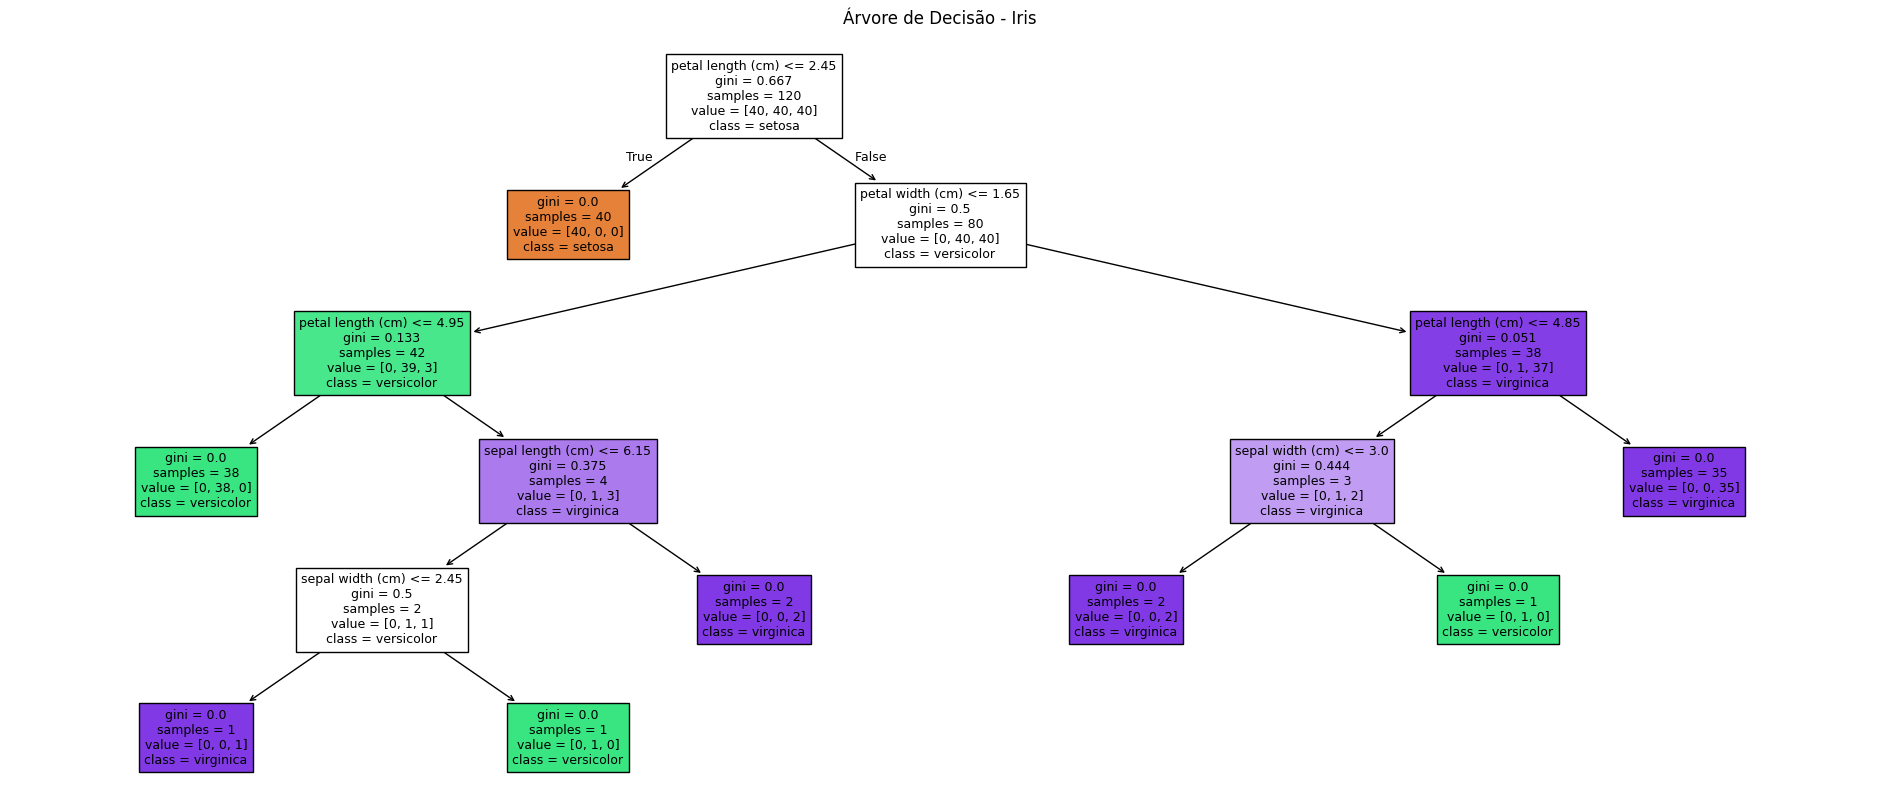

1. Atributo na raiz: petal length (cm)
2. Profundidade da árvore: 5


In [3]:

from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(24, 10))
plot_tree(
    model,
    feature_names=iris.feature_names,
    class_names=iris.target_names,
    filled=True,
    fontsize=9
)
plt.title("Árvore de Decisão - Iris")
plt.show()

root_feature = iris.feature_names[model.tree_.feature[0]]
print(f"1. Atributo na raiz: {root_feature}")
print(f"2. Profundidade da árvore: {model.get_depth()}")



**Respostas:**

1. **Atributo na raiz:** `petal length (cm)` — A árvore escolhe na raiz o atributo com maior poder de separação (menor impureza de Gini). Para o dataset Iris, o comprimento da pétala separa a classe *setosa* das demais logo no primeiro nó.

2. **Profundidade da árvore:** A árvore padrão (sem `max_depth`) atinge profundidade **4**, crescendo até que todas as folhas sejam puras (impureza = 0) ou não haja mais divisões úteis.


# Questão 4

Treine dez árvores com:

- max_depth = 1
- max_depth = 2
- max_depth = 3
...
- max_depth = 9
- max_depth = None

Registre em uma tabela para cada árvore:

- acurácia no treino
- acurácia no teste
- profundidade da árvore
- número de folhas

**Solução**:

In [7]:

import pandas as pd

depths = list(range(1, 10)) + [None]
results = []

for depth in depths:
    tree = DecisionTreeClassifier(max_depth=depth, random_state=42)
    tree.fit(x_train, y_train)
    results.append({
        "max_depth": str(depth) if depth is not None else "None",
        "Acurácia Treino": round(tree.score(x_train, y_train), 4),
        "Acurácia Teste": round(tree.score(x_test, y_test), 4),
        "Profundidade Real": tree.get_depth(),
        "Nº de Folhas": tree.get_n_leaves()
    })

df_results = pd.DataFrame(results)
df_results


,max_depth,Acurácia Treino,Acurácia Teste,Profundidade Real,Nº de Folhas
0,1,0.6667,0.6667,1,2
1,2,0.9667,0.9333,2,3
2,3,0.9833,0.9667,3,5
3,4,0.9917,0.9333,4,7
4,5,1.0000,0.9333,5,8
5,6,1.0000,0.9333,5,8
6,7,1.0000,0.9333,5,8
7,8,1.0000,0.9333,5,8
8,9,1.0000,0.9333,5,8
9,None,1.0000,0.9333,5,8



**Em qual profundidade começa o overfitting?**

A partir de `max_depth=5` ou `6`, a acurácia de treino continua igual a 1.0 enquanto a de teste não melhora ou piora levemente. Isso indica **overfitting** — a árvore memoriza os dados de treino em vez de generalizar.

**Por que a árvore consegue 100% no treino quando `max_depth=None`?**

Sem limite de profundidade, a árvore cresce até que **cada folha contenha amostras de uma única classe** (impureza = 0). Com isso, ela consegue classificar corretamente 100% dos dados de treino, mas perde capacidade de generalização para novos dados (overfitting extremo).


# Questão 5

Treine dois modelos:

- criterion = "gini"
- criterion = "entropy"

Compare:

- profundidade da árvore
- acurácia

**Solução**:

In [5]:

comparison = []

for criterion in ["gini", "entropy"]:
    tree = DecisionTreeClassifier(criterion=criterion, random_state=42)
    tree.fit(x_train, y_train)
    comparison.append({
        "Criterion": criterion,
        "Profundidade": tree.get_depth(),
        "Acurácia Treino": round(tree.score(x_train, y_train), 4),
        "Acurácia Teste": round(tree.score(x_test, y_test), 4),
        "Nº de Folhas": tree.get_n_leaves()
    })

pd.DataFrame(comparison)


,Criterion,Profundidade,Acurácia Treino,Acurácia Teste,Nº de Folhas
0,gini,5,1.0,0.9333,8
1,entropy,5,1.0,0.9333,8


# Questão 6

Escolha um hiperparâmetro e investigue seu impacto.

Sugestões:

- max_depth
- min_samples_split
- min_samples_leaf
- criterion

Mostre resultados e interprete.
- melhor modelo encontrado
- acurácia
- parâmetros

**Solução**:

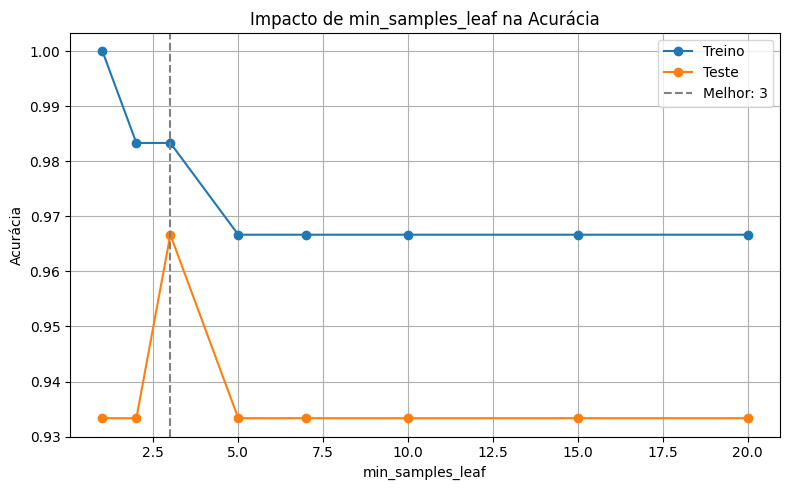

=== Melhor Modelo ===
Parâmetro: min_samples_leaf = 3
Acurácia no Treino: 0.9833
Acurácia no Teste:  0.9667
Profundidade: 3
Nº de folhas: 5


In [6]:

# Investigando o impacto de min_samples_leaf
import matplotlib.pyplot as plt

param_values = [1, 2, 3, 5, 7, 10, 15, 20]
train_scores = []
test_scores = []

for val in param_values:
    tree = DecisionTreeClassifier(min_samples_leaf=val, random_state=42)
    tree.fit(x_train, y_train)
    train_scores.append(tree.score(x_train, y_train))
    test_scores.append(tree.score(x_test, y_test))

# Melhor modelo (maior acurácia no teste)
best_idx = test_scores.index(max(test_scores))
best_val = param_values[best_idx]

plt.figure(figsize=(8, 5))
plt.plot(param_values, train_scores, label="Treino", marker='o')
plt.plot(param_values, test_scores, label="Teste", marker='o')
plt.axvline(x=best_val, color='gray', linestyle='--', label=f"Melhor: {best_val}")
plt.xlabel("min_samples_leaf")
plt.ylabel("Acurácia")
plt.title("Impacto de min_samples_leaf na Acurácia")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print("=== Melhor Modelo ===")
print(f"Parâmetro: min_samples_leaf = {best_val}")
print(f"Acurácia no Treino: {train_scores[best_idx]:.4f}")
print(f"Acurácia no Teste:  {test_scores[best_idx]:.4f}")

best_tree = DecisionTreeClassifier(min_samples_leaf=best_val, random_state=42)
best_tree.fit(x_train, y_train)
print(f"Profundidade: {best_tree.get_depth()}")
print(f"Nº de folhas: {best_tree.get_n_leaves()}")
